In [4]:
%load_ext autoreload
%autoreload 2

from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
from search_inputs import inputs, getSearchMap, download_location
import os
from ipyleaflet import Map, basemaps

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
inputs

Box(children=(Dropdown(description='Orbit:', options=('ascending', 'descending'), value='ascending'), DatePick…

In [6]:
m, searchState = getSearchMap(inputs, basemap=basemaps.Esri.WorldImagery)
m

Map(center=[37.5531, -109.6914], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

["'type': 'REVERSE': 'report': Reversed polygon winding order"]


## Select a path
Once selected, the next cell will show you the footprints of the scenes that will actually be downloaded.

In [7]:
paths = searchState.pathSelector()
paths

Dropdown(description='Relative Orbit:', options=(34, 106), value=34)

In [9]:
# searchState.summaryMap(basemap=basemaps.Esri.WorldImagery)
searchState.summaryMap()

Map(center=[37.5531, -109.6914], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

In [10]:
print(searchState.scenes2download)

[<asf_search.Products.NISARProduct.NISARProduct object at 0x7f04b7479350>, <asf_search.Products.NISARProduct.NISARProduct object at 0x7f04b70eeb50>, <asf_search.Products.NISARProduct.NISARProduct object at 0x7f04b70ef810>]


## File Preparation and Download/Mosaic
The following cells aggregate scenes by date, and then use gdal's vsicurl prefixes to download cropped and mosaiced scenes of just your study area.

### First pick a download location

In [11]:
download_location

Text(value='/', description='Folder:', placeholder='//Enter/Valid/Folder/Paths')

In [12]:
dates = [scene.properties['startTime'].split('T')[0] for scene in searchState.scenes2download]
udates = np.unique(np.array(dates))
print(f'Number of dates: {len(udates)}')

frames = [scene.properties['frameNumber'] for scene in searchState.scenes2download]
uframes = np.unique(np.array(frames))
# for scene in searchState.scenes2download:
#     print(scene.properties['url'])

Number of dates: 3


In [13]:
download_folder = download_location.value

if not os.path.exists(download_folder):
    os.makedirs(download_folder)

target_extent = searchState.search_coordinates
latitudes = [coord[1] for coord in searchState.search_coordinates]
longitudes = [coord[0] for coord in searchState.search_coordinates]
te = f'{np.min(longitudes)} {np.min(latitudes)} {np.max(longitudes)} {np.max(latitudes)}'

In [14]:
bash_script = ''
bash_path = os.path.join(download_folder, './dl.sh')

for d in udates:
    files2download = [scene.properties['url'] for scene in searchState.scenes2download if d in scene.properties['startTime']]
    outpath = os.path.join(download_folder, f"./{d.replace('-', '')}.tif")
    bandName = '/science/LSAR/GSLC/grids/frequencyA/HH'
    files2download = [f'NETCDF:/vsicurl/{file}:{bandName}' for file in files2download]
    gdal_command = f"gdalwarp -te {te} -te_srs EPSG:4326 -srcnodata nan -dstnodata nan -r lanczos -wo INIT_DEST=NO_DATA -multi -wo NUM_THREADS=ALL_CPUS \
        -of GTiff -overwrite {' '.join(files2download)} {outpath}"
    bash_script += gdal_command + '\n'

with open(bash_path, "w") as dlsh:
    dlsh.write(bash_script)

## Run download script
The for-loop above generates the gdal commmands for downloading the GSLCS to disk so that they can be run either in this notebook or also in a screen while the terminal is closed. To run in a screen, 
```
screen -S dlnisar
bash <bash_path.sh>
```
Then press `ctr+a d` to allow the downloads to run in the background.

Or run the script directly from this notebook below.

In [15]:
!bash {bash_path}

Creating output file that is 3003P x 2556L.
Processing NETCDF:/vsicurl/https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GSLC_BETA_V1/NISAR_L2_PR_GSLC_007_034_A_019_4005_DHDH_A_20251206T130825_20251206T130900_X05009_N_F_J_001/NISAR_L2_PR_GSLC_007_034_A_019_4005_DHDH_A_20251206T130825_20251206T130900_X05009_N_F_J_001.h5:/science/LSAR/GSLC/grids/frequencyA/HH [1/1] : 0...10...20...30...40...50...60...70.Creating output file that is 3003P x 2556L.
Processing NETCDF:/vsicurl/https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GSLC_BETA_V1/NISAR_L2_PR_GSLC_009_034_A_019_4005_DHDH_A_20251230T130826_20251230T130901_X05009_N_F_J_001/NISAR_L2_PR_GSLC_009_034_A_019_4005_DHDH_A_20251230T130826_20251230T130901_X05009_N_F_J_001.h5:/science/LSAR/GSLC/grids/frequencyA/HH [1/1] : 0...10...20...30...40...50...60...70.Creating output file that is 3003P x 2556L.
Processing NETCDF:/vsicurl/https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GSLC_BETA_V1/NISAR_L2_PR_GSLC_010_034_A_019_4005

## Preview Data
Load the first image below and seee if it looks alright!

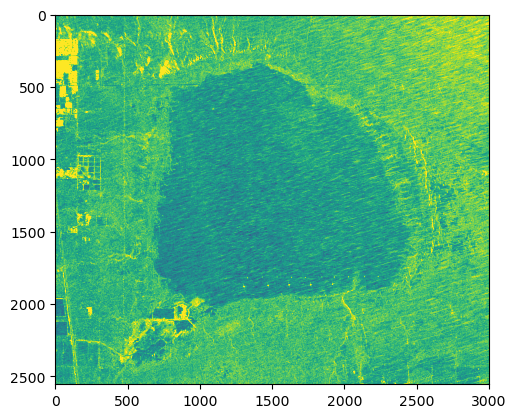

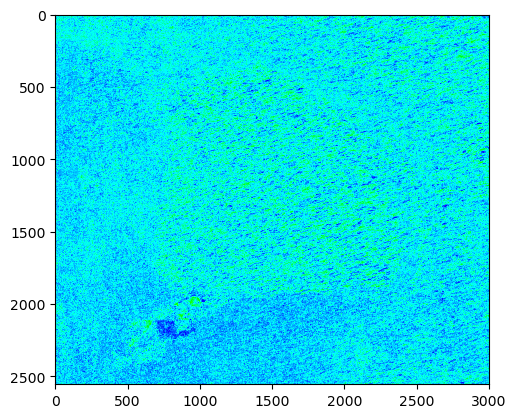

In [21]:
import glob
import rasterio
gslc_paths = glob.glob(os.path.join(download_folder, './*.tif'))
slc1 = rasterio.open(gslc_paths[0]).read(1)
slc2 = rasterio.open(gslc_paths[1]).read(1)

plt.imshow(10 * np.log10(np.abs(slc1)), vmin=-15, vmax=-5)
plt.show()
plt.imshow(np.angle(slc2 * slc1.conj()), vmin=-np.pi, vmax=np.pi, cmap='hsv')
plt.show()